# Decision Tree Models

Small interpretable decision tree for fall and return-to-hospital labels.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
import joblib

In [ ]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for path in candidates:
        dataset_path = path / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
        if dataset_path.exists():
            return path
        if (path / "src").exists() and (path / "outputs").exists():
            return path
    raise FileNotFoundError("Could not locate repo root with outputs/datavision_weekly_2023-08_2025-01.parquet")


def find_snapshot_col(df: pd.DataFrame) -> str:
    candidates = [
        "snapshot_date",
        "snapshot_dt",
        "snapshot",
        "reference_date",
        "as_of_date",
        "week_start",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ["snapshot", "reference", "as_of", "week", "date", "dt", "time"])]
    for col in date_cols:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            return col
    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce")
        if parsed.notna().mean() >= 0.9:
            return col
    raise ValueError("No snapshot date column found.")


def ensure_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "fall_next_30d" not in df.columns and "label_fall_30d" in df.columns:
        df = df.rename(columns={"label_fall_30d": "fall_next_30d"})
    if "rth_next_30d" not in df.columns and "label_rth_30d" in df.columns:
        df = df.rename(columns={"label_rth_30d": "rth_next_30d"})
    missing = [c for c in ["fall_next_30d", "rth_next_30d"] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing label columns: {missing}")
    return df


def temporal_split(df: pd.DataFrame, date_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])
    train_end = pd.Timestamp("2024-07-01")
    val_end = pd.Timestamp("2024-11-01")
    train = df[df[date_col] < train_end]
    val = df[(df[date_col] >= train_end) & (df[date_col] < val_end)]
    test = df[df[date_col] >= val_end]
    return train, val, test


def prepare_features(
    df: pd.DataFrame,
    label_col: str,
    columns: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.Series]:
    id_cols = [c for c in ["resident_id", "facility_id", "patient_id", "person_id"] if c in df.columns]
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "dt", "time", "snapshot", "as_of", "week", "reference"])]
    drop_cols = set(id_cols + date_cols + [label_col, "fall_next_30d", "rth_next_30d"])
    if columns is None:
        numeric_cols = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").select_dtypes(include=["number"]).columns
        X = df[numeric_cols].copy()
        missing_rate = X.isna().mean()
        X = X.loc[:, missing_rate <= 0.95]
        constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
        X = X.drop(columns=constant_cols)
    else:
        base = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
        X = base.reindex(columns=columns)
    days_cols = [c for c in X.columns if "days_since_last" in c]
    X.loc[:, days_cols] = X[days_cols].fillna(365)
    y = df[label_col].astype(int)
    return X, y


def impute_median(X: pd.DataFrame, fallback: pd.Series | None = None) -> pd.DataFrame:
    med = X.median()
    if fallback is not None:
        med = med.fillna(fallback)
    return X.fillna(med)


def threshold_at_k(y_score: np.ndarray, k: float = 0.10) -> float:
    n_top = max(1, int(len(y_score) * k))
    return float(np.sort(y_score)[-n_top])

In [3]:
root = find_repo_root(Path.cwd())
dataset_path = root / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
df = pd.read_parquet(dataset_path)
df = ensure_labels(df)
date_col = find_snapshot_col(df)
train_df, val_df, test_df = temporal_split(df, date_col)
df.shape, train_df.shape, val_df.shape, test_df.shape

((64089, 204), (34772, 204), (16251, 204), (13066, 204))

In [4]:
def load_top_features(root: Path, label_col: str, top_n: int = 50) -> list[str]:
    label_map = {
        "fall_next_30d": "label_fall_30d",
        "rth_next_30d": "label_rth_30d",
    }
    label_name = label_map.get(label_col, label_col)
    path = root / "outputs" / f"selected_features_top100_{label_name}.csv"
    if path.exists():
        features = pd.read_csv(path)["feature"].dropna().astype(str).tolist()
        return features[:top_n]
    return []


def select_features_by_mi(X: pd.DataFrame, y: pd.Series, top_k: int = 50) -> list[str]:
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
    return mi_series.head(top_k).index.tolist()


def drop_correlated(X: pd.DataFrame, threshold: float = 0.95) -> list[str]:
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return to_drop


def top_k_metrics(y_true: np.ndarray, y_score: np.ndarray, k: float = 0.10) -> tuple[float, float]:
    if len(y_true) == 0:
        return 0.0, 0.0
    n_top = max(1, int(len(y_true) * k))
    order = np.argsort(-y_score)
    top_true = y_true[order][:n_top]
    positives = float(top_true.sum())
    recall_at_k = positives / max(1.0, float(y_true.sum()))
    precision_at_k = positives / float(n_top)
    return recall_at_k, precision_at_k


def evaluate_tree_split(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    metrics = {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
        "threshold": float(threshold),
    }
    metrics["predicted_positive_rate"] = float(y_pred.mean())
    recall_at_10pct, precision_at_10pct = top_k_metrics(y_true, y_score, k=0.10)
    metrics["recall_at_10pct"] = float(recall_at_10pct)
    metrics["precision_at_10pct"] = float(precision_at_10pct)
    return metrics


def train_tree_for_label(label_col: str, model_name: str):
    X_train, y_train = prepare_features(train_df, label_col)
    feature_cols = X_train.columns.tolist()
    X_val, y_val = prepare_features(val_df, label_col, columns=feature_cols)
    X_test, y_test = prepare_features(test_df, label_col, columns=feature_cols)

    val_missing = sorted(set(X_train.columns) - set(X_val.columns))
    val_extra = sorted(set(X_val.columns) - set(X_train.columns))
    test_missing = sorted(set(X_train.columns) - set(X_test.columns))
    test_extra = sorted(set(X_test.columns) - set(X_train.columns))

    print(f"{model_name}: val missing {len(val_missing)}, val extra {len(val_extra)}")
    print(f"{model_name}: test missing {len(test_missing)}, test extra {len(test_extra)}")
    if val_missing or val_extra:
        print(f"{model_name}: val drift sample", (val_missing + val_extra)[:10])
    if test_missing or test_extra:
        print(f"{model_name}: test drift sample", (test_missing + test_extra)[:10])

    train_median = X_train.median()
    X_train = impute_median(X_train, fallback=train_median)
    X_val = impute_median(X_val, fallback=train_median)
    X_test = impute_median(X_test, fallback=train_median)

    top_features = load_top_features(root, label_col, top_n=50)
    if not top_features:
        top_features = select_features_by_mi(X_train, y_train, top_k=50)
        print(f"{model_name}: top-50 list missing, using MI instead")

    top_features = [c for c in top_features if c in X_train.columns]
    if not top_features:
        raise ValueError(f"{model_name}: no matching features found for training")

    X_train_top = X_train[top_features]
    to_drop = drop_correlated(X_train_top, threshold=0.95)
    selected = [c for c in top_features if c not in to_drop]

    tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
    tree.fit(X_train[selected], y_train)

    y_score_val = tree.predict_proba(X_val[selected])[:, 1]
    y_score_test = tree.predict_proba(X_test[selected])[:, 1]
    threshold = threshold_at_k(y_score_val, k=0.10)

    metrics_val = evaluate_tree_split(y_val.values, y_score_val, threshold)
    metrics_test = evaluate_tree_split(y_test.values, y_score_test, threshold)

    return tree, metrics_val, metrics_test, selected, X_val[selected], y_val


fall_tree, fall_metrics_val, fall_metrics_test, fall_features, X_val_full, y_val_full = train_tree_for_label("fall_next_30d", "fall_tree")
rth_tree, rth_metrics_val, rth_metrics_test, rth_features, X_val_rth, y_val_rth = train_tree_for_label("rth_next_30d", "rth_tree")
fall_metrics_val, fall_metrics_test, rth_metrics_val, rth_metrics_test

fall_tree: val missing 0, val extra 0
fall_tree: test missing 0, test extra 0
rth_tree: val missing 0, val extra 0
rth_tree: test missing 0, test extra 0


({'precision': 0.2841007819287576,
  'recall': 0.490622655663916,
  'f1': 0.3598349381017882,
  'roc_auc': 0.8016251280945991,
  'pr_auc': 0.2897460366240867,
  'threshold': 0.21249151391717583,
  'predicted_positive_rate': 0.1416528213648391,
  'recall_at_10pct': 0.4021005251312828,
  'precision_at_10pct': 0.32984615384615384},
 {'precision': 0.27029972752043596,
  'recall': 0.5102880658436214,
  'f1': 0.3534022087638048,
  'roc_auc': 0.7875389779375688,
  'pr_auc': 0.2646805963716866,
  'threshold': 0.21249151391717583,
  'predicted_positive_rate': 0.14044083881830705,
  'recall_at_10pct': 0.41872427983539096,
  'precision_at_10pct': 0.3116385911179173},
 {'precision': 0.10746268656716418,
  'recall': 0.44353182751540043,
  'f1': 0.17300760913095714,
  'roc_auc': 0.7460812513318886,
  'pr_auc': 0.1551954390715649,
  'threshold': 0.06840390879478828,
  'predicted_positive_rate': 0.12368469632637992,
  'recall_at_10pct': 0.4106776180698152,
  'precision_at_10pct': 0.12307692307692308},

In [5]:
from datetime import datetime

reports_dir = root / "reports"
plots_dir = reports_dir / "plots"
models_dir = root / "models"
reports_dir.mkdir(exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(exist_ok=True)

run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
metrics_rows = [
    {"run_id": run_id, "model": "decision_tree", "target": "fall_next_30d", "split": "val", **fall_metrics_val},
    {"run_id": run_id, "model": "decision_tree", "target": "fall_next_30d", "split": "test", **fall_metrics_test},
    {"run_id": run_id, "model": "decision_tree", "target": "rth_next_30d", "split": "val", **rth_metrics_val},
    {"run_id": run_id, "model": "decision_tree", "target": "rth_next_30d", "split": "test", **rth_metrics_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = reports_dir / "model_metrics.csv"
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    metrics_df = pd.concat([existing, metrics_df], ignore_index=True)
metrics_df.to_csv(metrics_path, index=False)

joblib.dump(fall_tree, models_dir / "fall_tree_model.pkl")
joblib.dump(rth_tree, models_dir / "rth_tree_model.pkl")

fall_perm = permutation_importance(fall_tree, X_val_full, y_val_full, n_repeats=10, random_state=42)
fall_importance = pd.DataFrame(
    {
        "model": "decision_tree",
        "target": "fall_next_30d",
        "feature": X_val_full.columns,
        "importance": fall_perm.importances_mean,
    }
).sort_values("importance", ascending=False)

rth_perm = permutation_importance(rth_tree, X_val_rth, y_val_rth, n_repeats=10, random_state=42)
rth_importance = pd.DataFrame(
    {
        "model": "decision_tree",
        "target": "rth_next_30d",
        "feature": X_val_rth.columns,
        "importance": rth_perm.importances_mean,
    }
).sort_values("importance", ascending=False)

feature_df = pd.concat([fall_importance, rth_importance], ignore_index=True)
feature_path = reports_dir / "feature_importance_decision_tree.csv"
feature_df.to_csv(feature_path, index=False)

metrics_df.tail(6)

,run_id,model,target,split,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,recall_at_10pct,precision_at_10pct,threshold
74,20260309T045642Z,decision_tree,rth_next_30d,val,0.632911,0.102669,0.176678,0.762457,0.159482,0.004861,0.386037,0.115692,NaN
75,20260309T045642Z,decision_tree,rth_next_30d,test,0.660714,0.107246,0.184539,0.779984,0.161390,0.004286,0.460870,0.121746,NaN
76,20260309T050811Z,decision_tree,fall_next_30d,val,0.284101,0.490623,0.359835,0.801625,0.289746,0.141653,0.402101,0.329846,0.212492
77,20260309T050811Z,decision_tree,fall_next_30d,test,0.270300,0.510288,0.353402,0.787539,0.264681,0.140441,0.418724,0.311639,0.212492
78,20260309T050811Z,decision_tree,rth_next_30d,val,0.107463,0.443532,0.173008,0.746081,0.155195,0.123685,0.410678,0.123077,0.068404
79,20260309T050811Z,decision_tree,rth_next_30d,test,0.107514,0.539130,0.179277,0.768761,0.152775,0.132405,0.460870,0.121746,0.068404


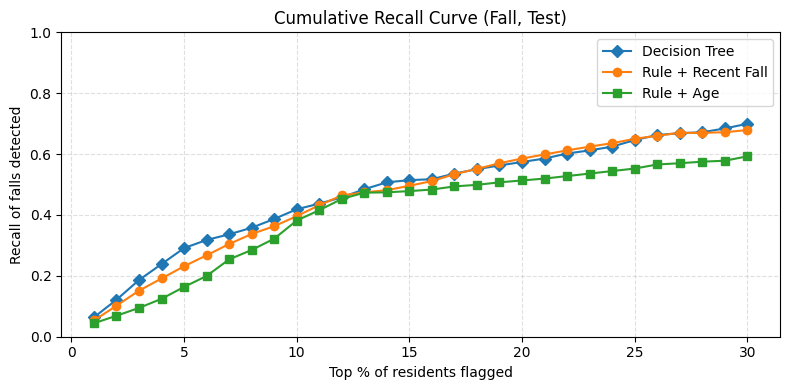

In [6]:
def recall_curve(y_true: np.ndarray, y_score: np.ndarray, max_pct: int = 30) -> tuple[np.ndarray, np.ndarray]:
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    total_pos = max(1.0, float(y_sorted.sum()))
    recalls = []
    percents = np.arange(1, max_pct + 1)
    for pct in percents:
        n_top = max(1, int(len(y_sorted) * (pct / 100.0)))
        recalls.append(float(y_sorted[:n_top].sum()) / total_pos)
    return percents, np.array(recalls)

X_train_full, y_train_full = prepare_features(train_df, "fall_next_30d")
train_median_full = X_train_full.median()
X_train_full = impute_median(X_train_full, fallback=train_median_full)
X_test_full, y_test_full = prepare_features(test_df, "fall_next_30d", columns=X_train_full.columns.tolist())
X_test_full = impute_median(X_test_full, fallback=train_median_full)

y_score_tree = fall_tree.predict_proba(X_test_full[fall_features])[:, 1]
percents, recalls_tree = recall_curve(y_test_full.values, y_score_tree, max_pct=30)

points_path = reports_dir / "rule_cumulative_recall_points.csv"
rule_points = pd.read_csv(points_path)
fall_recent = rule_points[(rule_points["target"] == "fall_next_30d") & (rule_points["tiebreaker"] == "recent_fall")].sort_values("percent_flagged")
fall_age = rule_points[(rule_points["target"] == "fall_next_30d") & (rule_points["tiebreaker"] == "age")].sort_values("percent_flagged")

plt.figure(figsize=(8, 4))
plt.plot(percents, recalls_tree, marker="D", linewidth=1.5, label="Decision Tree")
plt.plot(fall_recent["percent_flagged"], fall_recent["recall"], marker="o", linewidth=1.5, label="Rule + Recent Fall")
plt.plot(fall_age["percent_flagged"], fall_age["recall"], marker="s", linewidth=1.5, label="Rule + Age")
plt.xlabel("Top % of residents flagged")
plt.ylabel("Recall of falls detected")
plt.title("Cumulative Recall Curve (Fall, Test)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

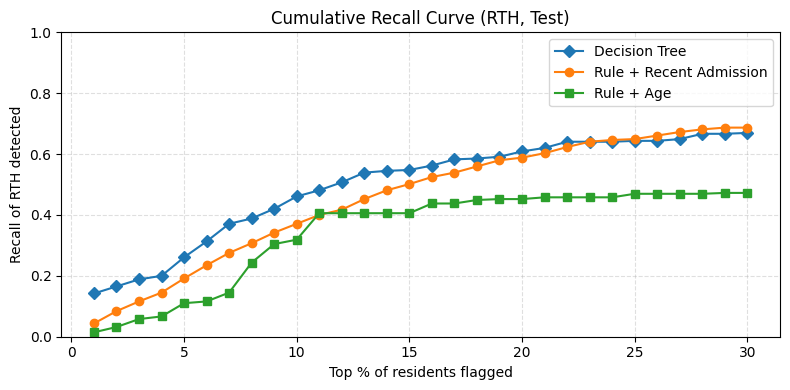

In [7]:
X_train_rth, y_train_rth = prepare_features(train_df, "rth_next_30d")
train_median_rth = X_train_rth.median()
X_train_rth = impute_median(X_train_rth, fallback=train_median_rth)
X_test_rth, y_test_rth = prepare_features(test_df, "rth_next_30d", columns=X_train_rth.columns.tolist())
X_test_rth = impute_median(X_test_rth, fallback=train_median_rth)

y_score_rth_tree = rth_tree.predict_proba(X_test_rth[rth_features])[:, 1]
percents_rth, recalls_rth_tree = recall_curve(y_test_rth.values, y_score_rth_tree, max_pct=30)

rth_recent = rule_points[(rule_points["target"] == "rth_next_30d") & (rule_points["tiebreaker"] == "recent_admission")].sort_values("percent_flagged")
if rth_recent.empty:
    rth_recent = rule_points[(rule_points["target"] == "rth_next_30d") & (rule_points["tiebreaker"] == "recent_transfer")].sort_values("percent_flagged")
rth_age = rule_points[(rule_points["target"] == "rth_next_30d") & (rule_points["tiebreaker"] == "age")].sort_values("percent_flagged")

plt.figure(figsize=(8, 4))
plt.plot(percents_rth, recalls_rth_tree, marker="D", linewidth=1.5, label="Decision Tree")
plt.plot(rth_recent["percent_flagged"], rth_recent["recall"], marker="o", linewidth=1.5, label="Rule + Recent Admission")
plt.plot(rth_age["percent_flagged"], rth_age["recall"], marker="s", linewidth=1.5, label="Rule + Age")
plt.xlabel("Top % of residents flagged")
plt.ylabel("Recall of RTH detected")
plt.title("Cumulative Recall Curve (RTH, Test)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
export_rows = []
for pct, rec in zip(percents, recalls_tree):
    export_rows.append({"model": "decision_tree", "target": "fall_next_30d", "percent_flagged": int(pct), "recall": float(rec)})
for pct, rec in zip(percents_rth, recalls_rth_tree):
    export_rows.append({"model": "decision_tree", "target": "rth_next_30d", "percent_flagged": int(pct), "recall": float(rec)})

export_df = pd.DataFrame(export_rows)
export_path = reports_dir / "decision_tree_cumulative_recall_points.csv"
export_df.to_csv(export_path, index=False)
export_path, export_df.head(8)

(PosixPath('/Users/marcelo.florencio/workspace/personal/tricura-incident-risk/reports/decision_tree_cumulative_recall_points.csv'),
            model         target  percent_flagged    recall
 0  decision_tree  fall_next_30d                1  0.063786
 1  decision_tree  fall_next_30d                2  0.121399
 2  decision_tree  fall_next_30d                3  0.186214
 3  decision_tree  fall_next_30d                4  0.238683
 4  decision_tree  fall_next_30d                5  0.291152
 5  decision_tree  fall_next_30d                6  0.317901
 6  decision_tree  fall_next_30d                7  0.336420
 7  decision_tree  fall_next_30d                8  0.358025)